# 14 — Comparaison finale des quatre modèles

Ce notebook charge les artefacts sans réentraîner. Le **gagnant du protocole** maximise le macro-F1 de validation. La **généralisation test observée** est mesurée après gel de l'architecture, de la perte et du seuil ; elle ne modifie jamais la sélection.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from src.config import *
from src.evaluation import binary_metrics, collect_probabilities, per_subject_metrics, prediction_table, select_threshold
from src.helpers import count_parameters, set_seed
from src.training import pos_weight_from_labels, save_model_artifacts, train_with_early_stopping

set_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Périphérique :", device, "| CUDA :", torch.cuda.is_available())

Périphérique : cuda | CUDA : True


In [2]:
MODEL_SPECS = [
    ("MLP", "statistical features", ["mlp"]),
    ("CNN 2D", "BVP/EDA/ACC-magnitude scalograms", ["cnn2d"]),
    ("RNN", "normalized raw sequences", ["rnn_fair", "rnn"]),
    ("LSTM", "normalized raw sequences", ["lstm_fair", "lstm"]),
]
ALLOWED_MODELS = {"MLP", "CNN 2D", "RNN", "LSTM"}

def load_row(model, representation, candidates):
    row = {"model": model, "input representation": representation, "status": "missing artifact"}
    for directory in candidates:
        path = PROJECT_ROOT / "artifacts/models" / directory
        required = ["model_config.json", "validation_metrics.json", "test_metrics.json", "training_summary.json", "threshold.json"]
        if not all((path / item).exists() for item in required): continue
        config, validation, test, summary, threshold = [json.loads((path / item).read_text(encoding="utf-8")) for item in required]
        architecture = config.get("architecture", {})
        hidden = architecture.get("hidden_size", config.get("hidden_size")) if isinstance(architecture, dict) else config.get("hidden_size")
        if model in {"RNN", "LSTM"} and hidden not in {None, 32}:
            row["status"] = f"incompatible artifact ({directory}: hidden_size={hidden})"; continue
        row.update({"status": "available", "artifact directory": directory, "parameter count": config.get("parameter_count"),
            "best validation epoch": summary.get("best_epoch", config.get("best_validation_epoch")), "validation macro F1": validation.get("macro_f1"),
            "test macro F1": test.get("macro_f1"), "weighted F1": test.get("weighted_f1"), "stress precision": test.get("stress_precision"),
            "stress recall": test.get("stress_recall"), "ROC-AUC": test.get("roc_auc"), "average precision": test.get("average_precision"),
            "selected threshold": threshold.get("threshold"), "training time": summary.get("training_time_seconds"),
            "inference time": test.get("inference_time_seconds")})
        break
    return row

comparison = pd.DataFrame([load_row(*spec) for spec in MODEL_SPECS])
assert set(comparison.model) == ALLOWED_MODELS and len(comparison) == 4
display(comparison)
missing = comparison[comparison.status != "available"]
if len(missing): print("Artefacts manquants ou incompatibles :", missing[["model", "status"]].to_dict("records"))

,model,input representation,status,artifact directory,parameter count,best validation epoch,validation macro F1,test macro F1,weighted F1,stress precision,stress recall,ROC-AUC,average precision,selected threshold,training time,inference time
0,MLP,statistical features,available,mlp,18433,3,0.879317,0.856275,0.882933,0.900000,0.703125,0.950110,0.905258,0.66,0.839510,0.004852
1,CNN 2D,BVP/EDA/ACC-magnitude scalograms,available,cnn2d,89473,10,0.862566,0.843993,0.874975,0.953488,0.640625,0.973023,0.939067,0.79,4.623403,0.035250
2,RNN,normalized raw sequences,available,rnn_fair,1825,10,0.750730,0.435170,0.508717,0.226415,0.281250,0.647966,0.427894,0.43,2.947827,0.013937
3,LSTM,normalized raw sequences,available,lstm_fair,6209,4,0.797137,0.621518,0.704128,0.615385,0.312500,0.694238,0.573333,0.54,2.220442,0.012224


## Gagnant du protocole et généralisation observée

Gagnant du protocole (validation) : MLP
Généralisation test observée après gel : 0.8562753036437247


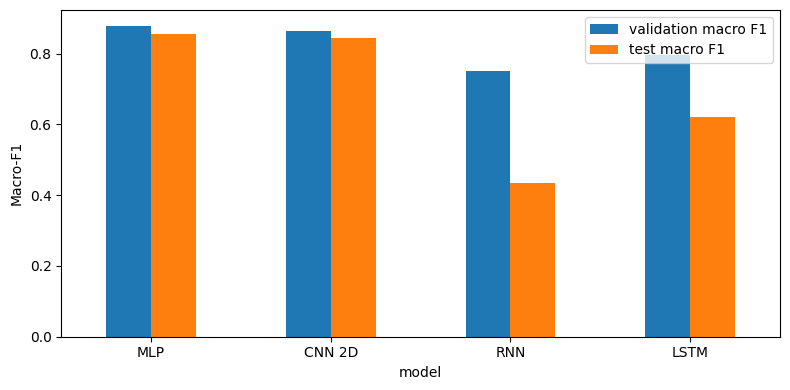

In [3]:
available = comparison[comparison.status == "available"].copy()
if len(available):
    winner = available.loc[available["validation macro F1"].idxmax()]
    print("Gagnant du protocole (validation) :", winner.model)
    print("Généralisation test observée après gel :", winner["test macro F1"])
    available.set_index("model")[["validation macro F1", "test macro F1"]].plot.bar(figsize=(8,4), rot=0)
    plt.ylabel("Macro-F1"); plt.tight_layout(); plt.show()

## Résultats par sujet

In [4]:
frames = []
for _, row in available.iterrows():
    path = PROJECT_ROOT / "artifacts/models" / row["artifact directory"] / "per_subject_metrics.csv"
    if path.exists():
        frame = pd.read_csv(path); frame.insert(0, "model", row.model); frames.append(frame)
per_subject_results = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
display(per_subject_results)

,model,subject_id,n_windows,accuracy,macro_f1,weighted_f1,non_stress_precision,non_stress_recall,stress_precision,stress_recall,confusion_matrix,roc_auc,average_precision
0,MLP,S11,144,0.993056,0.991765,0.993033,0.990099,1.000000,1.000000,0.977273,"[[100, 0], [1, 43]]",1.000000,1.000000
1,MLP,S14,144,0.930556,0.913462,0.928419,0.916667,0.990000,0.972222,0.795455,"[[99, 1], [9, 35]]",0.988864,0.976115
2,MLP,S2,138,0.731884,0.610675,0.701975,0.760684,0.908163,0.571429,0.300000,"[[89, 9], [28, 12]]",0.775765,0.560680
3,CNN 2D,S11,144,NaN,0.983636,0.986111,0.990000,0.990000,0.977273,0.977273,"[[99, 1], [1, 43]]",0.999091,0.998106
4,CNN 2D,S14,144,NaN,0.684211,0.755848,0.773438,0.990000,0.937500,0.340909,"[[99, 1], [29, 15]]",0.942955,0.875022
5,CNN 2D,S2,138,NaN,0.820779,0.860079,0.857143,0.979592,0.923077,0.600000,"[[96, 2], [16, 24]]",0.977551,0.886202
6,RNN,S11,144,0.715278,0.674442,0.719281,0.810526,0.770000,0.530612,0.590909,"[[77, 23], [18, 26]]",0.894091,0.807802
7,RNN,S14,144,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"[[0, 100], [44, 0]]",0.000000,0.174728
8,RNN,S2,138,0.782609,0.633628,0.731820,0.765625,1.000000,1.000000,0.250000,"[[98, 0], [30, 10]]",0.928061,0.835365
9,LSTM,S11,144,0.909722,0.896774,0.910992,0.957895,0.910000,0.816327,0.909091,"[[91, 9], [4, 40]]",0.985455,0.975955


## Synthèse

- MLP : représentation statistique globale.
- CNN 2D : motifs temps-fréquence locaux des scalogrammes.
- RNN : dépendances temporelles ordonnées via un état caché simple.
- LSTM : dépendances temporelles avec cellule mémoire et portes.

Une architecture plus complexe ne garantit pas une meilleure généralisation indépendante des sujets.